# ⚙️ Vehicle Maintenance Analysis & Prediction — Google Colab Edition
### Academic Machine Learning Project — Case Study No. 67

> **Instructions for Google Colab**:
> 1. Click **Runtime** -> **Run all** (`Ctrl + F9`) to execute all cells.
> 2. The dataset will be downloaded automatically.
> 3. All charts, models, cross-validation, and metrics will run inline.
> 4. The final cell launches the Streamlit dashboard via localtunnel.

In [1]:
# Step 1: Download dataset directly in Colab
import os
import sys
import urllib.request
from IPython.display import display, HTML

dataset_url = "https://huggingface.co/datasets/jskswamy/predictive-maintenance-data/raw/main/engine_data.csv"
dataset_path = "engine_data.csv"

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, dataset_path)
    print("✅ Dataset downloaded successfully (19,535 records)!")
else:
    print("✅ Dataset engine_data.csv is ready.")

✅ Dataset engine_data.csv is ready.


In [2]:
# Step 2: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import joblib

# Safe matplotlib style fallback
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
elif 'seaborn-whitegrid' in plt.style.available:
    plt.style.use('seaborn-whitegrid')
else:
    plt.style.use('default')

print("✅ All ML and Data Science libraries loaded successfully!")

✅ All ML and Data Science libraries loaded successfully!


In [3]:
# Step 3: Load Dataset & Verify Summary Statistics
df = pd.read_csv("engine_data.csv")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n=== DATA TYPES & MISSING VALUES ===")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})
display(info_df)
print("\n=== NUMERICAL STATISTICS ===")
display(df.describe().T)

Dataset Dimensions: 19535 rows, 7 columns

=== DATA TYPES & MISSING VALUES ===


,Data Type,Missing Values,Unique Values
Engine RPM,int64,0,1379
Lub Oil Pressure,float64,0,19534
Fuel Pressure,float64,0,19531
Coolant Pressure,float64,0,19534
Lub Oil Temp,float64,0,19530
Coolant Temp,float64,0,19532
Engine Condition,int64,0,2



=== NUMERICAL STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub Oil Pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel Pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant Pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
Lub Oil Temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant Temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


In [4]:
# Step 4: Verify Class Distribution & Duplicates
duplicates_count = df.duplicated().sum()
print(f"Duplicate Rows Count: {duplicates_count}\n")
print("Target Distribution (Engine Condition):")
target_counts = df['Engine Condition'].value_counts()
target_props = df['Engine Condition'].value_counts(normalize=True)

for k in target_counts.index:
    label = "Maintenance Required (1)" if k == 1 else "Normal Condition (0)"
    print(f"  Class {k} ({label}): {target_counts[k]} ({target_props[k]*100:.2f}%)")

Duplicate Rows Count: 0

Target Distribution (Engine Condition):
  Class 1 (Maintenance Required (1)): 12317 (63.05%)
  Class 0 (Normal Condition (0)): 7218 (36.95%)


## 4. Exploratory Data Analysis (EDA)

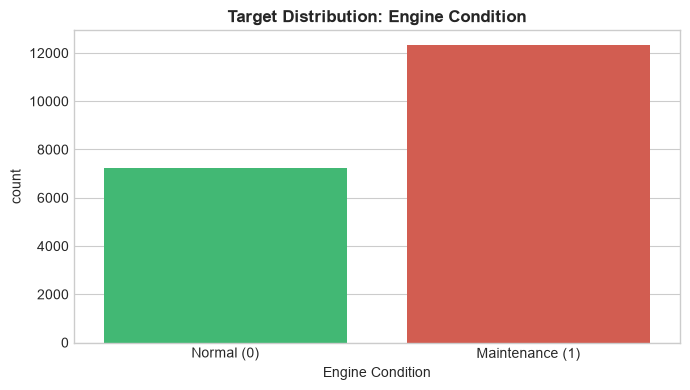

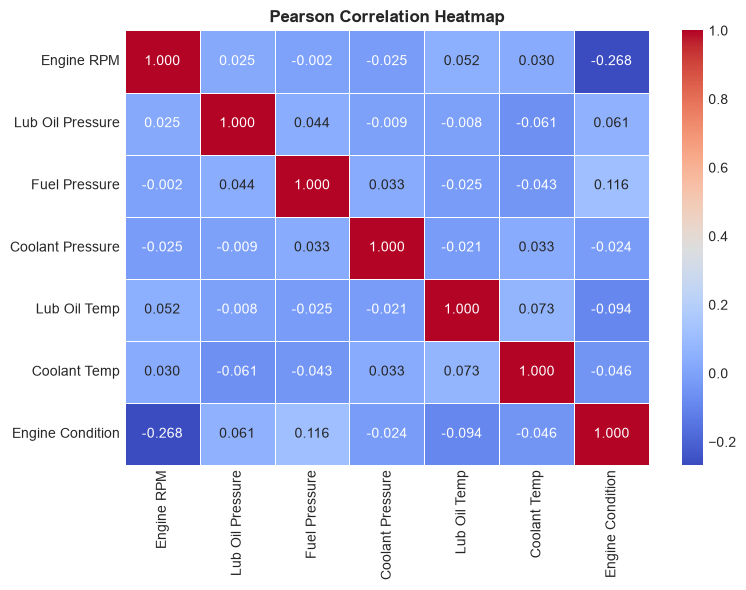

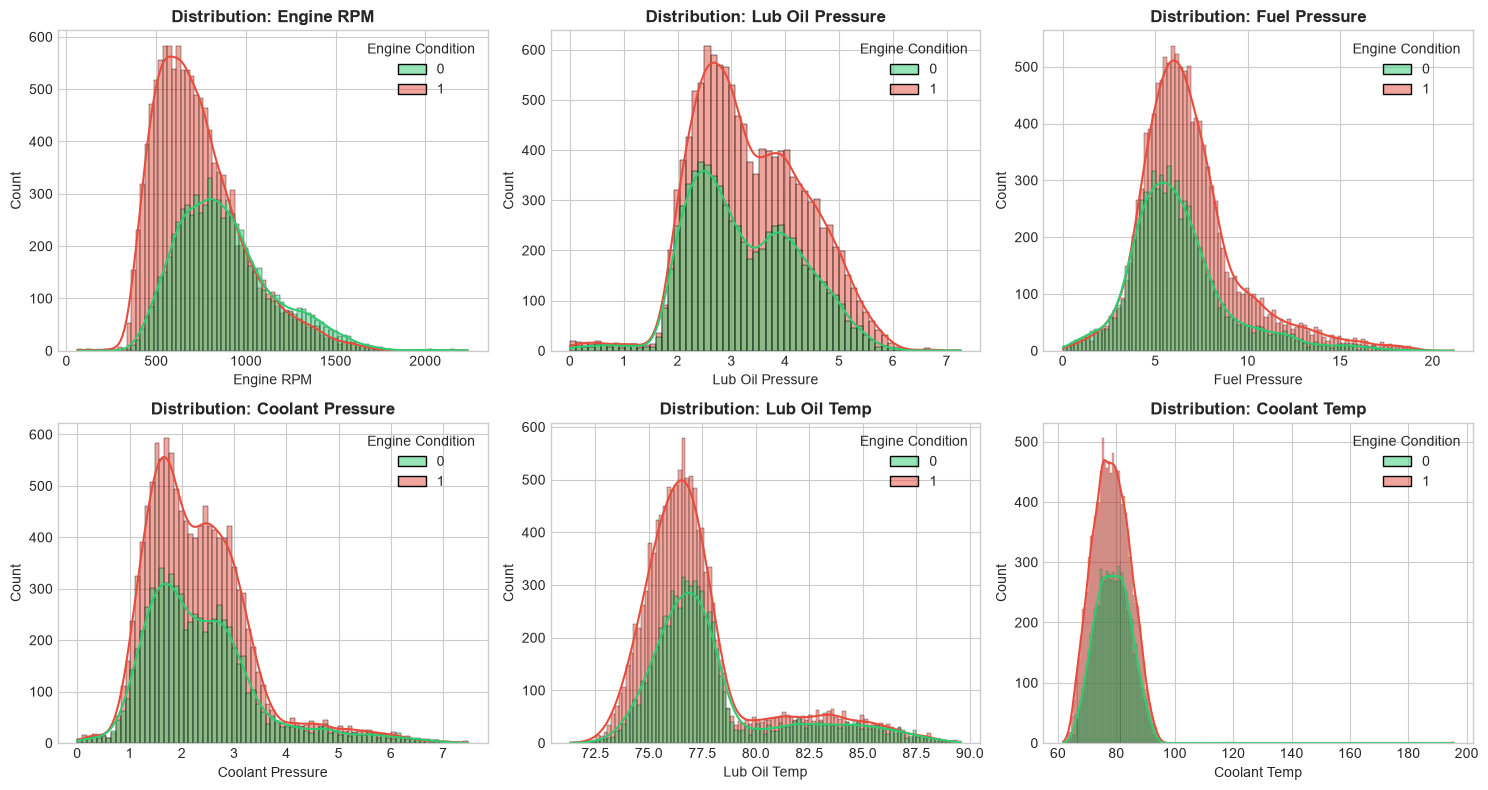

In [5]:
# 1. Target Distribution Plot
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Engine Condition', hue='Engine Condition', palette=['#2ecc71', '#e74c3c'], ax=ax, legend=False)
ax.set_title('Target Distribution: Engine Condition', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Normal (0)', 'Maintenance (1)'])
plt.tight_layout()
plt.show()

# 2. Pearson Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".3f", cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title('Pearson Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Feature Distributions
features = [c for c in df.columns if c != 'Engine Condition']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Engine Condition', kde=True, ax=axes[idx], palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.5)
    axes[idx].set_title(f'Distribution: {col}', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing & Train-Test Split (Preventing Data Leakage)

In [6]:
# 80/20 Stratified Train-Test Split & Feature Scaling
X = df.drop(columns=['Engine Condition'])
y = df['Engine Condition']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")
joblib.dump(feature_names, "feature_names.joblib")

print("✅ Preprocessing Complete!")
print(f"   Train Set: {X_train_scaled.shape[0]} samples")
print(f"   Test Set:  {X_test_scaled.shape[0]} samples")

✅ Preprocessing Complete!
   Train Set: 15628 samples
   Test Set:  3907 samples


## 6. Model Training, 5-Fold Cross-Validation & Evaluation

In [7]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=12),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

results = []
fitted_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training 5 classification models...")
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    fitted_models[name] = clf
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })

eval_df = pd.DataFrame(results)
print("\n=== ACTUAL EXPERIMENTAL MODEL PERFORMANCE COMPARISON ===")
display(eval_df.style.highlight_max(axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], color='#d1fae5'))

Training 5 classification models...


/Users/antriksh.manwadkar/ml_finalproject/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== ACTUAL EXPERIMENTAL MODEL PERFORMANCE COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.661121,0.678695,0.878197,0.765664,0.691760
1,K-Nearest Neighbors,0.626056,0.682182,0.761673,0.719739,0.617488
2,Decision Tree,0.637574,0.697622,0.750305,0.723005,0.639711
3,Random Forest,0.661889,0.690080,0.841657,0.758368,0.695675
4,Support Vector Machine,0.664448,0.676687,0.895656,0.770924,0.676626


## 7. Model Selection & Artifact Export

In [8]:
best_idx = eval_df['F1-Score'].idxmax()
best_model_name = eval_df.loc[best_idx, 'Model']
best_f1 = eval_df.loc[best_idx, 'F1-Score']
best_recall = eval_df.loc[best_idx, 'Recall']

print(f"🏆 Selected Production Model: {best_model_name}")
print(f"   Test F1-Score: {best_f1:.4f}")
print(f"   Test Recall:   {best_recall:.4f}")

final_model = fitted_models[best_model_name]
joblib.dump(final_model, "final_model.joblib")
print("✅ Saved final_model.joblib successfully!")

🏆 Selected Production Model: Support Vector Machine
   Test F1-Score: 0.7709
   Test Recall:   0.8957
✅ Saved final_model.joblib successfully!


## 8. Error Analysis & Confusion Matrix

=== CONFUSION MATRIX BREAKDOWN ===
True Negatives (TN)  : 390
False Positives (FP) : 1054  (False Alarms)
False Negatives (FN) : 257  (Uncaught Faults)
True Positives (TP)  : 2206


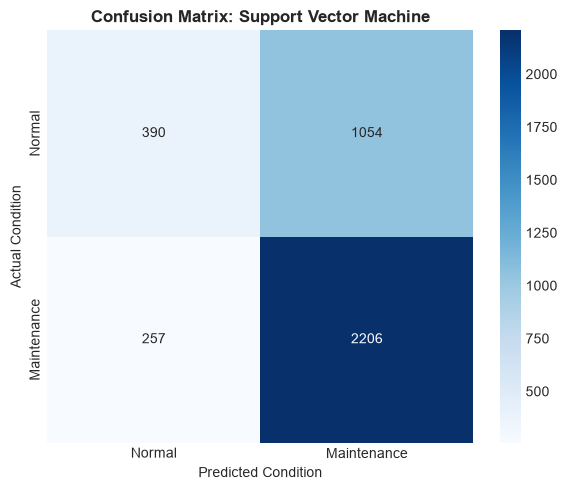

In [9]:
y_pred_final = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print("=== CONFUSION MATRIX BREAKDOWN ===")
print(f"True Negatives (TN)  : {tn}")
print(f"False Positives (FP) : {fp}  (False Alarms)")
print(f"False Negatives (FN) : {fn}  (Uncaught Faults)")
print(f"True Positives (TP)  : {tp}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Normal", "Maintenance"], yticklabels=["Normal", "Maintenance"])
ax.set_title(f'Confusion Matrix: {best_model_name}', fontweight='bold')
ax.set_ylabel('Actual Condition')
ax.set_xlabel('Predicted Condition')
plt.tight_layout()
plt.show()

## 9. Streamlit Dashboard Setup

In [10]:
# Create app.py for Streamlit deployment
app_code = '''import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.set_page_icon("⚙️")
st.title("⚙️ Vehicle Maintenance Analysis Dashboard")

@st.cache_resource
def load_models():
    return joblib.load("final_model.joblib"), joblib.load("scaler.joblib"), joblib.load("feature_names.joblib")

try:
    model, scaler, features = load_models()
    rpm = st.number_input("Engine RPM", 50.0, 3000.0, 700.0)
    lub_p = st.number_input("Lub Oil Pressure (bar)", 0.0, 10.0, 2.49)
    fuel_p = st.number_input("Fuel Pressure (bar)", 0.0, 30.0, 11.79)
    cool_p = st.number_input("Coolant Pressure (bar)", 0.0, 10.0, 3.17)
    lub_t = st.number_input("Lub Oil Temp (°C)", 50.0, 120.0, 84.14)
    cool_t = st.number_input("Coolant Temp (°C)", 50.0, 220.0, 81.63)

    if st.button("PREDICT MAINTENANCE REQUIREMENT"):
        inp = scaler.transform(pd.DataFrame([[rpm, lub_p, fuel_p, cool_p, lub_t, cool_t]], columns=features))
        pred = model.predict(inp)[0]
        prob = model.predict_proba(inp)[0]
        if pred == 1:
            st.error(f"⚠️ MAINTENANCE REQUIRED (Confidence: {np.max(prob)*100:.2f}%)")
        else:
            st.success(f"✅ NORMAL CONDITION (Confidence: {np.max(prob)*100:.2f}%)")
except Exception as e:
    st.error(f"Error loading model: {e}")
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("✅ app.py created successfully!")

✅ app.py created successfully!


## 10. Launch Streamlit Web Application in Colab

In [11]:
# Launch Streamlit and expose via localtunnel
import subprocess
import sys
import time

try:
    subprocess.Popen([sys.executable, "-m", "streamlit", "run", "app.py", "--server.port", "8501"])
    time.sleep(2)
    print("🔑 LOCALTUNNEL PASSWORD (Colab IP):")
    subprocess.run(["curl", "-s", "https://ipv4.icanhazip.com"])
    print("\n🌐 LOCALTUNNEL URL:")
    subprocess.run(["npx", "-y", "localtunnel", "--port", "8501"])
except Exception as e:
    print("Notice:", e)

2026-10-02 01:07:52.427 Port 8501 is not available


🔑 LOCALTUNNEL PASSWORD (Colab IP):
49.36.109.156

🌐 LOCALTUNNEL URL:


your url is: https://slow-numbers-fail.loca.lt
